# Random Forest:

---

## Importing Libraries:

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

## Importing Dataset:

In [2]:
data = pd.read_csv("Cleaned Laptop Dataset.csv")

In [3]:
data.drop(columns=['Unnamed: 0'], inplace=True)

## Building Model:

In [4]:
X = data.drop(columns=['Price'])
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [5]:
preprocessing = ColumnTransformer(transformers=[
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment', 'Brand', 'Operating System', 'CPU Brand', 'CPU Segment', 'CPU Series']) 
], remainder='passthrough')

X_train_encoded = preprocessing.fit_transform(X_train)
X_test_encoded = preprocessing.transform(X_test)

n_estimators=100 | OOB score=83.33
n_estimators=200 | OOB score=83.55
n_estimators=300 | OOB score=83.61
n_estimators=400 | OOB score=83.71
n_estimators=500 | OOB score=83.72
n_estimators=600 | OOB score=83.75
n_estimators=700 | OOB score=83.74
n_estimators=800 | OOB score=83.76
n_estimators=900 | OOB score=83.76
n_estimators=1000 | OOB score=83.79


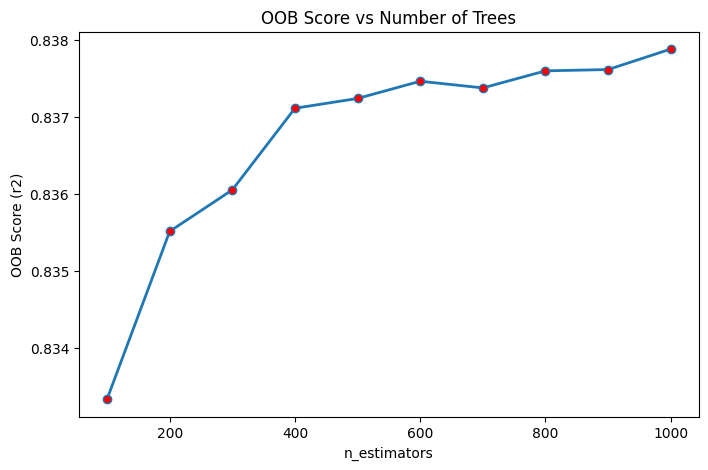

In [6]:
n_estimators_range = range(100, 1001, 100)
oob_scores = []

rf = RandomForestRegressor(max_depth=None, bootstrap=True, oob_score=True, n_jobs=-1, warm_start=True, random_state=69)

for i in n_estimators_range:
    rf.set_params(n_estimators=i)
    rf.fit(X_train_encoded, y_train)
    oob_scores.append(rf.oob_score_)
    print(f"n_estimators={i} | OOB score={rf.oob_score_ * 100:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_estimators_range), oob_scores, linewidth=2, marker='o',  markerfacecolor='red')
plt.xlabel('n_estimators')
plt.ylabel('OOB Score (r2)')
plt.title('OOB Score vs Number of Trees')
plt.show()

In [7]:
param = {'n_estimators' : list(range(500, 1001, 100)),
        'criterion' : ['squared_error', 'absolute_error'],
        'max_features' : ['sqrt', 1]}

grid = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=param,
    scoring='r2',
    n_jobs=-1,
    cv=5
)

grid.fit(X_train_encoded, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_ * 100:.2f}%")

Best Parameters: {'criterion': 'absolute_error', 'max_features': 'sqrt', 'n_estimators': 700}
Best Score: 84.63%


In [8]:
rf = RandomForestRegressor(n_estimators=700, criterion='absolute_error', max_features='sqrt', n_jobs=-1)

start_time = time.time()
rf.fit(X_train_encoded, y_train)
end_time = time.time() - start_time

print('Model Trained Sucessfully!')
print(f'Time Taken For Training: {end_time:.2f}s')

Model Trained Sucessfully!
Time Taken For Training: 31.74s


## Results:

In [9]:
def adjusted_r2_score(y, y_pred):

    r2 = r2_score(y, y_pred)
    n = X.shape[0]
    k = X.shape[1]

    return 1 - ((1 - r2) * (n - 1) / (n - 1 - k))

In [10]:
# Results on Training Data:

y_pred_train = rf.predict(X_train_encoded)

print(f"r2 Score (Trainig Data): {r2_score(y_train, y_pred_train) * 100 :.2f}%")
print(f"\nmean absolute error(Training Data): {mean_absolute_percentage_error(y_train, y_pred_train) * 100 :.2f}%")
print(f"\nadjusted r2 Score: {adjusted_r2_score(y_train, y_pred_train) * 100 :.2f}%")

r2 Score (Trainig Data): 97.61%

mean absolute error(Training Data): 6.61%

adjusted r2 Score: 97.60%


In [11]:
# Results on Testing Data:

y_pred_test = rf.predict(X_test_encoded)

print(f"r2 Score (Testing Data): {r2_score(y_test, y_pred_test) * 100 :.2f}%")
print(f"\nmean absolute error (Testing Data): {mean_absolute_percentage_error(y_test, y_pred_test) * 100 :.2f}%")
print(f"\nadjusted r2 Score: {adjusted_r2_score(y_test, y_pred_test) * 100 :.2f}%")

r2 Score (Testing Data): 86.23%

mean absolute error (Testing Data): 16.24%

adjusted r2 Score: 86.20%


## Cross-Val-Score:

In [12]:
preprocessing = ColumnTransformer(transformers=[
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment', 'Brand', 'Operating System', 'CPU Brand', 'CPU Segment', 'CPU Series']) 
], remainder='passthrough')

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(n_estimators=700, criterion='absolute_error', max_features='sqrt', n_jobs=-1))
])

In [13]:
print(f"r2 Score: {np.mean(cross_val_score(estimator=rf_pipeline, X=X, y=y, scoring='r2', cv=10, n_jobs=-1)) * 100 :.2f}%")

r2 Score: 84.60%


In [14]:
print(f"mean absolute error: {-np.mean(cross_val_score(estimator=rf_pipeline, X=X, y=y, scoring='neg_mean_absolute_percentage_error', cv=10, n_jobs=-1)) * 100 :.2f}%")

mean absolute error: 16.39%


---

# Experiment:

- ## Transformation (target feature):

In [15]:
preprocessing = ColumnTransformer(transformers=[
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment', 'Brand', 'Operating System', 'CPU Brand', 'CPU Segment', 'CPU Series'])
], remainder='passthrough')

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor())
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

param = {'regressor__model__n_estimators' : list(range(500, 1001, 100)),
        'regressor__model__criterion' : ['squared_error', 'absolute_error'],
        'regressor__model__max_features' : ['sqrt', 1]}

grid_model = GridSearchCV(
    estimator=rf_model,
    param_grid=param,
    scoring='r2',
    n_jobs=-1,
    cv=5
)

grid_model.fit(X_train, y_train)

print(f"Best Parameters: {grid_model.best_params_}")

Best Parameters: {'regressor__model__criterion': 'squared_error', 'regressor__model__max_features': 'sqrt', 'regressor__model__n_estimators': 700}


In [16]:
preprocessing = ColumnTransformer(transformers=[
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment', 'Brand', 'Operating System', 'CPU Brand', 'CPU Segment', 'CPU Series'])
], remainder='passthrough')

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(criterion='squared_error', max_features='sqrt', n_estimators=700))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

print(f"r2 Score: {np.mean(cross_val_score(estimator=rf_model, X=X, y=y, scoring='r2', cv=10, n_jobs=-1)) * 100 :.2f}%")

print(f"\nmean absolute error: {-np.mean(cross_val_score(estimator=rf_model, X=X, y=y, scoring='neg_mean_absolute_percentage_error', cv=10, n_jobs=-1)) * 100 :.2f}%")

r2 Score: 83.37%

mean absolute error: 15.38%


# Conclusion:

- *Random Forest* performs best, compared to *Linear Regression*, *SVM*, *KNN*, *Decision Trees* with an **r2-Score = 84.60% & M.A.P.E = 16.39%**.